In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# ===============================
# SETTINGS
# ===============================
fs = 250
dt_ms = 1000 / fs

input_lengths_plot = [10, 20, 30, 40, 50]
pred_lengths_plot = [1, 10]

# ===============================
# FOLDERS
# ===============================
folders = {
    "DynML": "results_all_selected_patients_multiPara_seeds_icentiaData",
    "MLP":   "results_all_selected_patients_MLP",
    "LSTM":  "results_all_selected_patients_LSTM",
    "TCN":   "results_all_selected_patients_TCN",
}

# ===============================
# LOAD DATA FUNCTION
# ===============================
def load_results(folder):
    all_files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".csv")
    ]
    
    df_list = []
    for f in all_files:
        try:
            df_list.append(pd.read_csv(f))
        except:
            continue
    
    if len(df_list) == 0:
        return pd.DataFrame()
    
    return pd.concat(df_list, ignore_index=True)


# ===============================
# LOAD ALL MODELS
# ===============================
model_dfs = {}

for model, folder in folders.items():
    print(f"Loading {model}...")
    model_dfs[model] = load_results(folder)
    print(f"{model} rows:", len(model_dfs[model]))

Loading DynML...
DynML rows: 128007
Loading MLP...
MLP rows: 44998
Loading LSTM...
LSTM rows: 26998
Loading TCN...
TCN rows: 26998


In [2]:
for model, df in model_dfs.items():

    print("\n" + "="*60)
    print(f"MODEL: {model}")
    print("="*60)

    print("\nTotal rows:")
    print(len(df))

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nColumn-wise unique counts:")
    for col in df.columns:
        try:
            nunique = df[col].nunique()
            print(f"{col}: {nunique}")
        except:
            pass


MODEL: DynML

Total rows:
128007

Columns:
['Patient', 'Data_seed', 'Reservoir_seed', 'input_len', 'Pred_len', 'N', 'Regime_ID', 'Train_MSE', 'Train_r', 'Train_RMSE', 'Avg_Topological_Entropy', 'Val_MSE', 'Val_r', 'Val_RMSE', 'Val_Entropy', 'Test_MSE', 'Test_r', 'Test_RMSE', 'Test_Entropy', 'Param_Means', 'Param_Stds', 'Online_results', 'Avg_First_Detection_Time_All', 'Avg_First_Detection_Time_Normal', 'Avg_First_Detection_Time_Arrhythmic', 'Std_First_Detection_Time_Arrhythmic']

Column-wise unique counts:
Patient: 50
Data_seed: 1
Reservoir_seed: 10
input_len: 5
Pred_len: 2
N: 16
Regime_ID: 7
Train_MSE: 128007
Train_r: 128007
Train_RMSE: 128007
Avg_Topological_Entropy: 100556
Val_MSE: 128007
Val_r: 128007
Val_RMSE: 128007
Val_Entropy: 86806
Test_MSE: 128007
Test_r: 128007
Test_RMSE: 128007
Test_Entropy: 104622
Param_Means: 460
Param_Stds: 453
Online_results: 128007
Avg_First_Detection_Time_All: 94676
Avg_First_Detection_Time_Normal: 31011
Avg_First_Detection_Time_Arrhythmic: 71881
Std

In [3]:
# ===============================
# BUILD DATA STRUCTURE
# ===============================
data_all_models = {}

for model, df in model_dfs.items():

    if df.empty:
        continue

    for _, row in df.iterrows():

        patient = str(row["Patient"]).strip()
        input_len = int(row["input_len"])
        pred_len = int(row["Pred_len"])

        try:
            online = json.loads(row["Online_results"])
        except:
            continue

        f1_vals = np.array([entry["f1"] for entry in online], dtype=float)

        data_all_models.setdefault(model, {}) \
                       .setdefault(patient, {}) \
                       .setdefault(input_len, {}) \
                       .setdefault(pred_len, []) \
                       .append(f1_vals)

print("Data loaded for models:", list(data_all_models.keys()))

Data loaded for models: ['DynML', 'MLP', 'LSTM', 'TCN']


In [4]:
input_lengths_plot = [10, 20, 30]


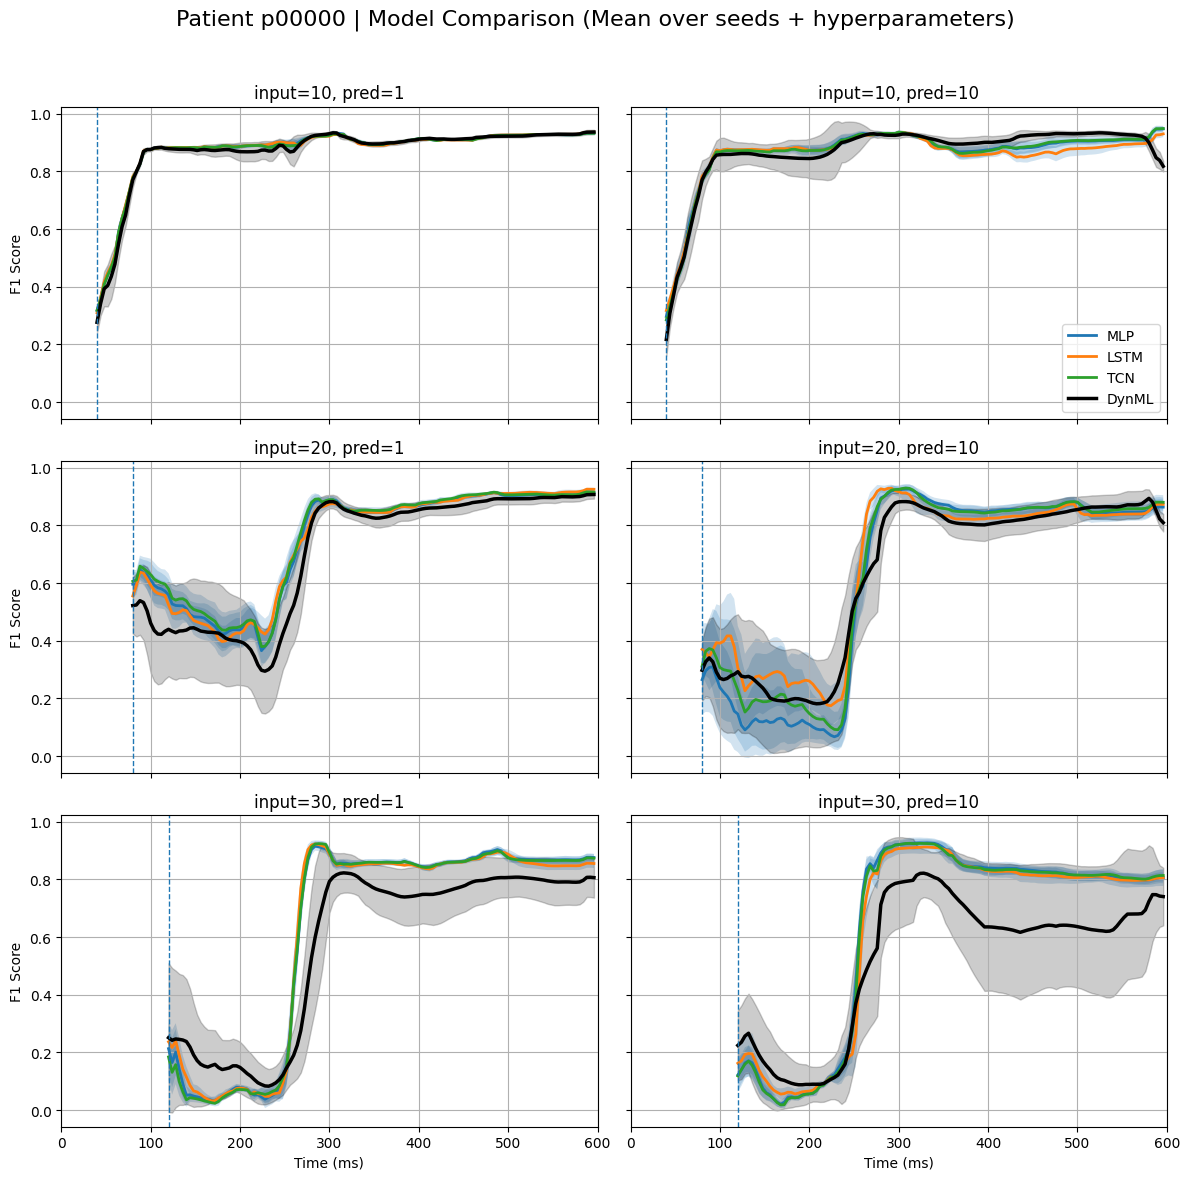

In [5]:
# ===============================
# FIGURE: MODEL COMPARISON (ONE PATIENT)
# ===============================

patient_id = "p00000"   # <<< CHANGE

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True, sharey=True)

for i, input_len in enumerate(input_lengths_plot):
    for j, pred_len in enumerate(pred_lengths_plot):

        ax = axes[i, j]

        for model in ["MLP", "LSTM", "TCN", "DynML"]:  # DynML LAST
            
            if model not in data_all_models:
                continue
            if patient_id not in data_all_models[model]:
                continue
            if input_len not in data_all_models[model][patient_id]:
                continue
            if pred_len not in data_all_models[model][patient_id][input_len]:
                continue

            curves = data_all_models[model][patient_id][input_len][pred_len]

            if len(curves) == 0:
                continue

            # ---- align lengths ----
            min_len = min(len(c) for c in curves)
            curves_array = np.array([c[:min_len] for c in curves])

            mean_f1 = np.mean(curves_array, axis=0)
            std_f1 = np.std(curves_array, axis=0)

            # correct time axis
            time_axis = (np.arange(min_len) + input_len) * dt_ms

            color = "black" if model == "DynML" else None

            ax.plot(
                time_axis,
                mean_f1,
                label=model,
                color=color,
                linewidth=2.5 if model == "DynML" else 2.0
            )
            
            ax.fill_between(
                time_axis,
                mean_f1 - std_f1,
                mean_f1 + std_f1,
                alpha=0.2,
                color=color
            )

        # ---- formatting ----
        ax.set_xlim(0, 150 * dt_ms)
        ax.axvline(x=input_len * dt_ms, linestyle='--', linewidth=1)

        ax.set_title(f"input={input_len}, pred={pred_len}")
        ax.grid(True)

# ---- labels ----
for ax in axes[-1, :]:
    ax.set_xlabel("Time (ms)")

for ax in axes[:, 0]:
    ax.set_ylabel("F1 Score")

axes[0, 1].legend()

fig.suptitle(
    f"Patient {patient_id} | Model Comparison (Mean over seeds + hyperparameters)",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [6]:

save_dir = "figures_model_comparison_all_patients"
os.makedirs(save_dir, exist_ok=True)

input_lengths_plot = [10, 20, 30]
pred_lengths_plot = [1, 10]

# ===============================
# LOOP OVER ALL PATIENTS
# ===============================
for patient_id in sorted(data_all_models["MLP"].keys()):

    print(f"Plotting patient: {patient_id}")

    fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True, sharey=True)

    for i, input_len in enumerate(input_lengths_plot):
        for j, pred_len in enumerate(pred_lengths_plot):

            ax = axes[i, j]

            for model in ["MLP", "LSTM", "TCN", "DynML"]:  # DynML LAST

                if model not in data_all_models:
                    continue
                if patient_id not in data_all_models[model]:
                    continue
                if input_len not in data_all_models[model][patient_id]:
                    continue
                if pred_len not in data_all_models[model][patient_id][input_len]:
                    continue

                curves = data_all_models[model][patient_id][input_len][pred_len]

                if len(curves) == 0:
                    continue

                # ---- align lengths ----
                min_len = min(len(c) for c in curves)
                curves_array = np.array([c[:min_len] for c in curves])

                mean_f1 = np.mean(curves_array, axis=0)
                std_f1 = np.std(curves_array, axis=0)

                # ---- time axis ----
                time_axis = (np.arange(min_len) + input_len) * dt_ms

                color = "black" if model == "DynML" else None

                ax.plot(
                    time_axis,
                    mean_f1,
                    label=model,
                    color=color,
                    linewidth=2.8 if model == "DynML" else 1.8,
                    zorder=10 if model == "DynML" else 2
                )

                ax.fill_between(
                    time_axis,
                    mean_f1 - std_f1,
                    mean_f1 + std_f1,
                    alpha=0.15,
                    color=color
                )

            # ---- formatting ----
            ax.set_xlim(0, 150 * dt_ms)
            ax.axvline(x=input_len * dt_ms, linestyle='--', linewidth=1)
            ax.set_title(f"input={input_len}, pred={pred_len}")
            ax.grid(True)

    # ---- axis labels ----
    for ax in axes[-1, :]:
        ax.set_xlabel("Time (ms)")

    for ax in axes[:, 0]:
        ax.set_ylabel("F1 Score")

    axes[0, 1].legend(fontsize=8)

    fig.suptitle(
        f"Patient {patient_id} | Model Comparison (Mean over seeds + hyperparameters)",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # ===============================
    # SAVE FIGURE
    # ===============================
    save_path = os.path.join(save_dir, f"{patient_id}_model_comparison.png")
    plt.savefig(save_path, dpi=300)

    plt.close()

Plotting patient: p00000
Plotting patient: p00001
Plotting patient: p00002
Plotting patient: p00003
Plotting patient: p00004
Plotting patient: p00005
Plotting patient: p00006
Plotting patient: p00007
Plotting patient: p00008
Plotting patient: p00009
Plotting patient: p00010
Plotting patient: p00011
Plotting patient: p00012
Plotting patient: p00013
Plotting patient: p00014
Plotting patient: p00015
Plotting patient: p00016
Plotting patient: p00017
Plotting patient: p00018
Plotting patient: p00019
Plotting patient: p00020
Plotting patient: p00021
Plotting patient: p00022
Plotting patient: p00023
Plotting patient: p00024
Plotting patient: p00025
Plotting patient: p00026
Plotting patient: p00027
Plotting patient: p00028
Plotting patient: p00029
Plotting patient: p00030
Plotting patient: p00031
Plotting patient: p00032
Plotting patient: p00033
Plotting patient: p00034
Plotting patient: p00035
Plotting patient: p00036
Plotting patient: p00038
Plotting patient: p00039
Plotting patient: p00040


In [ ]:
# ==========================================================
# PLOTTING — SIDE BY SIDE
# ==========================================================
methods = ["MLP","TCN","LSTM","DynML"]
colors = {"MLP":"tab:blue","TCN":"tab:green","LSTM":"tab:red","DynML":"black"}

dt_ms = 1000 / 250
x_max = 150
x_ticks = np.arange(0, x_max + 1, 10)

fig, axes = plt.subplots(
    nrows=len(windows),
    ncols=2,
    figsize=(14, 4*len(windows)),
    sharex=True, sharey=True
)

if len(windows) == 1:
    axes = axes.reshape(1,2)

for r, W in enumerate(windows):

    # Convert input window W into milliseconds
    W_ms = W * dt_ms
    old_pred_ms = old_pred_len * dt_ms
    new_pred_ms = new_pred_len * dt_ms

    # --------------------------------------------
    # LEFT COLUMN → OLD DATA
    # --------------------------------------------
    ax = axes[r][0]
    df_pw = df_old[df_old["Window"] == W]

    for method in methods:
        df_m = df_pw[df_pw["Method"] == method]
        if df_m.empty:
            continue
        
        f1_matrix = []
        for _, row in df_m.iterrows():
            res = json.loads(row["Online_results"])
            f1_vec = [x["f1"] for x in res]
            f1_matrix.append(f1_vec)

        f1_matrix = np.array(f1_matrix)
        if f1_matrix.size == 0:
            continue
        
        f1_mean = f1_matrix.mean(axis=0)
        f1_std  = f1_matrix.std(axis=0)

        # Convert x-axis INTO ms
        x_axis = np.arange(W, W + len(f1_mean)) * dt_ms

        ax.plot(x_axis, f1_mean, color=colors[method], linewidth=2, label=method)
        ax.fill_between(x_axis, f1_mean-f1_std, f1_mean+f1_std,
                        color=colors[method], alpha=0.15)
        ax.set_ylim(0.2, 1.0)
        ax.set_yticks(np.arange(0.2, 1.01, 0.2))

        x_tick_ms = np.arange(0, x_max * dt_ms + 1, 50)   # ticks every 25 ms
        ax.set_xticks(x_tick_ms)

    ax.set_ylabel(f"Input window = {W} \n(~{W_ms:.1f} ms)\n\nF1 score", fontsize=16)

    if r == 0:
        ax.set_title(f"Prediction window = {old_pred_len}, \n(~{old_pred_ms:.1f} ms)", fontsize=18)

    ax.grid(True)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=14)

    # --------------------------------------------
    # RIGHT COLUMN → NEW DATA
    # --------------------------------------------
    ax2 = axes[r][1]
    df_pw2 = df_new[df_new["Window"] == W]

    for method in methods:
        df_m = df_pw2[df_pw2["Method"] == method]
        if df_m.empty:
            continue

        f1_matrix = []
        for _, row in df_m.iterrows():
            res = json.loads(row["Online_results"])
            f1_vec = [x["f1"] for x in res]
            f1_matrix.append(f1_vec)

        f1_matrix = np.array(f1_matrix)
        if f1_matrix.size == 0:
            continue
        
        f1_mean = f1_matrix.mean(axis=0)
        f1_std  = f1_matrix.std(axis=0)

        # Convert x-axis to ms
        x_axis = np.arange(W, W + len(f1_mean)) * dt_ms

        ax2.plot(x_axis, f1_mean, color=colors[method], linewidth=2, label=method)
        ax2.fill_between(x_axis, f1_mean-f1_std, f1_mean+f1_std,
                         color=colors[method], alpha=0.15)

        ax2.set_ylim(0.0, 1.0)
        ax2.set_yticks(np.arange(0.2, 1.01, 0.2))


    if r == 0:
        ax2.set_title(f"Prediction window = {new_pred_len}, \n(~{new_pred_ms:.1f} ms)", fontsize=18)

    ax2.grid(True)
    ax2.tick_params(axis='x', labelsize=12)
    ax2.tick_params(axis='y', labelsize=14)

# ==========================================================
# GLOBAL LEGEND
# ==========================================================
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(methods), fontsize=20, frameon=False)

# ==========================================================
# GLOBAL X-AXIS LABEL (now in milliseconds)
# ==========================================================
fig.text(0.5, 0.04, "Time (ms)", ha='center', fontsize=22)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

fig.savefig(
    "Fig_online_F1_comparison_entropy_reservoirs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [6]:
#!/usr/bin/env python
# coding: utf-8

# ==========================================================
# MODEL COMPARISON FIGURE — ICENTIA11k
# Style: matches reference figure exactly
#   - Left column  = pred_len = 1
#   - Right column = pred_len = 10
#   - Rows         = input window lengths [10, 20, 30]
#   - Global legend at top
#   - Global x-axis label at bottom
#   - Time axis in ms (250 Hz)
# ==========================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# CONFIG
# ==========================================================

save_dir        = "figures_model_comparison_icentia_styled"
os.makedirs(save_dir, exist_ok=True)

input_lengths_plot = [10, 20, 30]
pred_lengths_plot  = [1, 10]

dt_ms    = 1000 / 250        # ms per sample at 250 Hz
beat_len = 150               # total beat length in samples

methods = ["MLP", "TCN", "LSTM", "DynML"]
colors  = {
    "MLP":   "tab:blue",
    "TCN":   "tab:green",
    "LSTM":  "tab:red",
    "DynML": "black",
}
linewidths = {"MLP": 1.8, "TCN": 1.8, "LSTM": 1.8, "DynML": 2.8}
zorders    = {"MLP": 2,   "TCN": 2,   "LSTM": 2,   "DynML": 10}

# x-axis: ticks every 50 ms up to beat_len * dt_ms
x_max_ms   = beat_len * dt_ms
x_tick_ms  = np.arange(0, x_max_ms + 1, 50)

# pred_len labels for column titles
pred_labels = {
    1:  "Prediction Horizon = 1 step\n(~{:.1f} ms)".format(1 * dt_ms),
    10: "Prediction Horizon = 10 steps\n(~{:.1f} ms)".format(10 * dt_ms),
}

# ==========================================================
# MAIN LOOP — ONE FIGURE PER PATIENT
# ==========================================================

for patient_id in sorted(data_all_models["MLP"].keys()):
    print("Plotting patient: {}".format(patient_id))

    fig, axes = plt.subplots(
        nrows=len(input_lengths_plot),
        ncols=len(pred_lengths_plot),
        figsize=(14, 4 * len(input_lengths_plot)),
        sharex=True,
        sharey=False,       # each row can have its own y-range
    )

    if len(input_lengths_plot) == 1:
        axes = axes.reshape(1, 2)

    for r, input_len in enumerate(input_lengths_plot):
        W_ms = input_len * dt_ms

        for c, pred_len in enumerate(pred_lengths_plot):
            ax = axes[r][c]

            for model in methods:      # DynML last → drawn on top
                if model not in data_all_models:
                    continue
                if patient_id not in data_all_models[model]:
                    continue
                if input_len not in data_all_models[model][patient_id]:
                    continue
                if pred_len not in data_all_models[model][patient_id][input_len]:
                    continue

                curves = data_all_models[model][patient_id][input_len][pred_len]
                if len(curves) == 0:
                    continue

                # Align curve lengths across seeds / hyperparams
                min_len      = min(len(c) for c in curves)
                curves_array = np.array([c[:min_len] for c in curves])
                mean_f1      = np.mean(curves_array, axis=0)
                std_f1       = np.std(curves_array,  axis=0)

                # Time axis starts at end of input window
                time_axis = (np.arange(min_len) + input_len) * dt_ms

                ax.plot(
                    time_axis, mean_f1,
                    color=colors[model],
                    linewidth=linewidths[model],
                    zorder=zorders[model],
                    label=model,
                )
                ax.fill_between(
                    time_axis,
                    mean_f1 - std_f1,
                    mean_f1 + std_f1,
                    color=colors[model],
                    alpha=0.15,
                    zorder=zorders[model] - 1,
                )

            # ---- formatting ----
            ax.set_xlim(0, x_max_ms)
            ax.set_xticks(x_tick_ms)
            ax.set_ylim(0, 1.0)
            ax.set_yticks(np.arange(0.0, 1.01, 0.2))
            ax.grid(True, alpha=0.4)
            ax.tick_params(axis='x', labelsize=12)
            ax.tick_params(axis='y', labelsize=12)

            # Column title — only on top row
            if r == 0:
                ax.set_title(pred_labels[pred_len], fontsize=16)

            # Row label — only on left column
            if c == 0:
                ax.set_ylabel(
                    "W={}\n(~{:.1f} ms)\n\nF1 Score".format(input_len, W_ms),
                    fontsize=14,
                )

    # ==========================================================
    # GLOBAL LEGEND — top centre, outside axes
    # ==========================================================
    handles, labels = axes[0, 0].get_legend_handles_labels()
    # deduplicate (in case multiple curves per method)
    seen    = {}
    h_dedup = []
    l_dedup = []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen[l] = True
            h_dedup.append(h)
            l_dedup.append(l)

    fig.legend(
        h_dedup, l_dedup,
        loc="upper center",
        ncol=len(methods),
        fontsize=18,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )

    # ==========================================================
    # GLOBAL X-AXIS LABEL — bottom centre
    # ==========================================================
    fig.text(0.5, 0.02, "Time (ms)", ha="center", fontsize=20)

    # Patient suptitle
    fig.suptitle(
        "Patient {}".format(patient_id),
        fontsize=18,
        y=1.04,
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])

    # ==========================================================
    # SAVE
    # ==========================================================
    save_path = os.path.join(
        save_dir, "{}_model_comparison.png".format(patient_id)
    )
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()
    print("  Saved: {}".format(save_path))

print("Done. All figures saved to: {}".format(save_dir))

Plotting patient: p00000
  Saved: figures_model_comparison_icentia_styled/p00000_model_comparison.png
Plotting patient: p00001
  Saved: figures_model_comparison_icentia_styled/p00001_model_comparison.png
Plotting patient: p00002
  Saved: figures_model_comparison_icentia_styled/p00002_model_comparison.png
Plotting patient: p00003
  Saved: figures_model_comparison_icentia_styled/p00003_model_comparison.png
Plotting patient: p00004
  Saved: figures_model_comparison_icentia_styled/p00004_model_comparison.png
Plotting patient: p00005
  Saved: figures_model_comparison_icentia_styled/p00005_model_comparison.png
Plotting patient: p00006
  Saved: figures_model_comparison_icentia_styled/p00006_model_comparison.png
Plotting patient: p00007
  Saved: figures_model_comparison_icentia_styled/p00007_model_comparison.png
Plotting patient: p00008
  Saved: figures_model_comparison_icentia_styled/p00008_model_comparison.png
Plotting patient: p00009
  Saved: figures_model_comparison_icentia_styled/p00009_m